# **Full Name: Chakradhar Redddy Yerragudi**

# **Uplevel Email Address: chakradharvasurama@gmail.com**

# **Name of the Problem Statement of Submission: Lending Club Loan Approval System**

# Lending Club Loan Approval System

## Business Background

Lending Club is a peer-to-peer lending company where individuals can borrow loans, and investors can fund those loans. Lending Club was founded in 2006 by Renaud Laplanche as a peer-to-peer (P2P) lending platform in San Francisco. It was one of the pioneers in the online lending space, where individual borrowers could obtain loans, and individual or institutional investors could invest in these loans to earn interest. The platform allowed for a more direct connection between lenders and borrowers, bypassing traditional banking intermediaries.

Read more here https://en.wikipedia.org/wiki/LendingClub

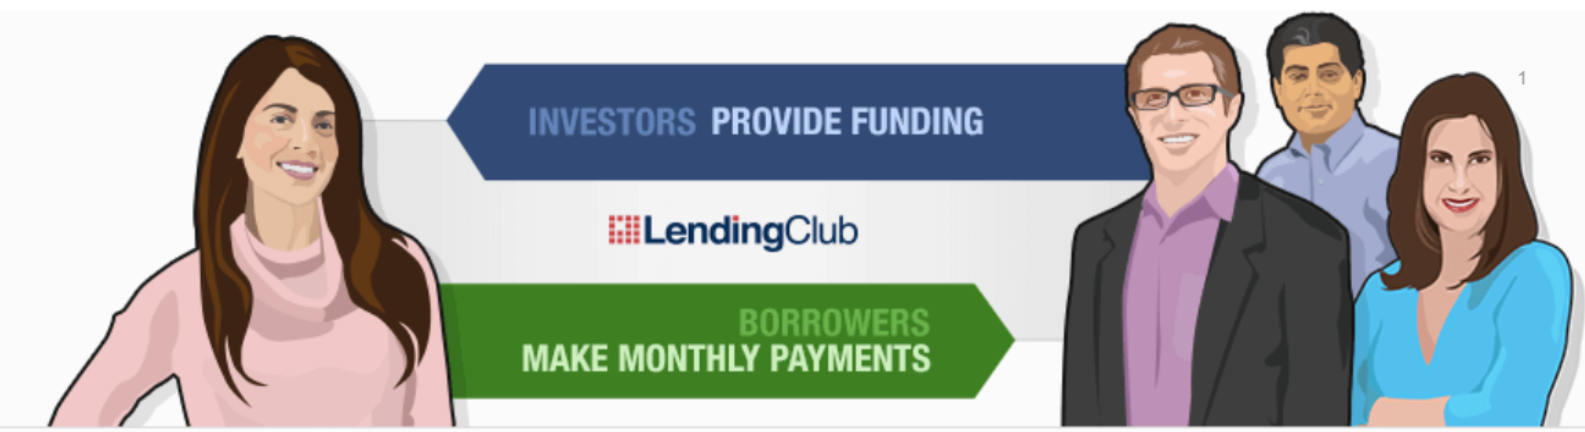

## Problem Statement

Now, whenever *Lending Club* approves a loan, there are two ways in which it is at risk:
- If LC approves a loan and the borrower fails to repay it on time
- If LC rejects a loan despite the borrower being capable of repaying the loan

Defaulting on loans can lead to significant financial losses for both the platform and investors. Similarly, not providing loans to credit-worthy customers can lead to missing out on potential revenue and profits. Therefore, a robust loan approval system is the need of the hour.

In the current loan approval process, underwriters evaluate loan applications by manually reviewing credit scores, income, debt, etc. and then, based on several parameters, either approve or reject a loan. This process is time-consuming and prone to errors.

Hence, Lending Club wants to build a loan approval system using Machine Learning models to automatically assess whether a given loan is likely to be repaid or whether the borrower is likely to default.

This is where you come in! As a budding data scientist, your goal is to help out Lending Club in creating this ML model that helps them predict whether a loan is likely to default or not.

## Data Understanding

You have been provided with around 38k loan application data from the Lending Club's website. The different columns and their description are mentioned below:

| Column Name         | Description                                                                                                                                                    |
|---------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| id                  | A unique LC assigned ID for the loan listing. *(Integer)*                                                                                                       |
| member_id           | A unique LC assigned ID for the borrower member. *(Integer)*                                                                                                    |
| loan_amnt           | The listed amount of the loan applied for by the borrower. If at some point the credit department reduces the loan amount, it will be reflected in this value. *(Float)* |
| term                | The number of payments on the loan. Values are in months and can be either 36 or 60. *(Integer)*                                                                 |
| int_rate            | Interest rate on the loan. *(Float)*                                                                                                                            |
| installment         | The monthly payment owed by the borrower if the loan originates. *(Float)*                                                                                       |
| grade               | LC assigned loan grade. *(Categorical/String)*                                                                                                                  |
| sub_grade           | LC assigned loan subgrade. *(Categorical/String)*                                                                                                               |
| emp_length          | Employment length in years. Possible values are between 0 and 10, where 0 means less than one year and 10 means ten or more years. *(Integer)*                   |
| home_ownership      | The home ownership status provided by the borrower during registration. Values are: RENT, OWN, MORTGAGE, OTHER. *(Categorical/String)*                           |
| annual_inc          | The self-reported annual income provided by the borrower during registration. *(Float)*                                                                         |
| verification_status | Indicates if income was verified by LC, not verified, or if the income source was verified. *(Categorical/String)*                                               |
| purpose             | A category provided by the borrower for the loan request. *(Categorical/String)*                                                                                |
| dti                 | A ratio calculated using the borrower’s total monthly debt payments (excluding mortgage and the requested LC loan), divided by the borrower’s self-reported income. *(Float)* |
| delinq_2yrs         | The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years. *(Integer)*                                         |
| inq_last_6mths      | The number of inquiries in the past 6 months (excluding auto and mortgage inquiries). *(Integer)*                                                                |
| open_acc            | The number of open credit lines in the borrower's credit file. *(Integer)*                                                                                       |
| pub_rec             | Number of derogatory public records. *(Integer)*                                                                                                                |
| revol_bal           | Total credit revolving balance. *(Float)*                                                                                                                       |
| revol_util          | Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. *(Float)*                             |
| total_acc           | The total number of credit lines currently in the borrower's credit file. *(Integer)*                                                                            |
| last_pymnt_amnt     | Last total payment amount received. *(Float)*                                                                                                                   |
| loan_status         | Current status of the loan. *(Categorical/String)*                                                                 
                  |

...

## Starter Code

### Necessary Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')

### Data Loading

In [ ]:
## Load the dataset
df=pd.read_csv('/content/loans.csv')

In [ ]:
## Observe the first few rows
## Do you observe any issues?
df.head()

,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,loan_status
0,1077501,1296599.0,5000.0,36 months,10.65%,162.87,B,B2,10+ years,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,3.0,0.0,13648.0,83.7%,9.0,171.62,Fully Paid
1,1077430,1314167.0,2500.0,60 months,15.27%,59.83,C,C4,< 1 year,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,3.0,0.0,1687.0,9.4%,4.0,119.66,Charged Off
2,1077175,1313524.0,2400.0,36 months,15.96%,84.33,C,C5,10+ years,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,2.0,0.0,2956.0,98.5%,10.0,649.91,Fully Paid
3,1076863,1277178.0,10000.0,36 months,13.49%,339.31,C,C1,10+ years,RENT,49200.0,Source Verified,other,20.00,0.0,1.0,10.0,0.0,5598.0,21%,37.0,357.48,Fully Paid
4,1075269,1311441.0,5000.0,36 months,7.90%,156.46,A,A4,3 years,RENT,36000.0,Source Verified,wedding,11.20,0.0,3.0,9.0,0.0,7963.0,28.3%,12.0,161.03,Fully Paid


In [ ]:
## Check the dataframe structure - datatypes and number of non-null rows
print(df.info())
print('\nLoan status distribution:')
print(df['loan_status'].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   38770 non-null  int64  
 1   member_id            38770 non-null  float64
 2   loan_amnt            38770 non-null  float64
 3   term                 38770 non-null  object 
 4   int_rate             38770 non-null  object 
 5   installment          38770 non-null  float64
 6   grade                38770 non-null  object 
 7   sub_grade            38770 non-null  object 
 8   emp_length           37734 non-null  object 
 9   home_ownership       38770 non-null  object 
 10  annual_inc           38770 non-null  float64
 11  verification_status  38770 non-null  object 
 12  purpose              38770 non-null  object 
 13  dti                  38770 non-null  float64
 14  delinq_2yrs          38770 non-null  float64
 15  inq_last_6mths       38770 non-null 

In [ ]:
## Check the shape
df.shape

(38770, 23)

In [ ]:
## Check the missing values across the columns
df.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,1036
home_ownership,0


#### Observations

- The dataset contains **38,770 rows and 23 columns**, indicating a moderately sized dataset suitable for machine learning.
- The target variable **`loan_status` is binary** with two classes:
  - **Fully Paid:** 33,136 (~85.5%)
  - **Charged Off:** 5,634 (~14.5%)
- The dataset is **highly imbalanced**, with default cases forming only ~14.5% of the data.
- Several columns that should be numeric are stored as **object (string) types**, including:
  - `term`
  - `int_rate`
  - `emp_length`
  - `revol_util`
- These columns contain **extra characters such as text labels and percentage signs**, and require cleaning and conversion to numeric format.
- Missing values are present but limited:
  - `emp_length` has **1,036 missing values**
  - `revol_util` has **50 missing values**
- The overall proportion of missing data is **less than 3%**, making imputation feasible.
- Columns such as **`id` and `member_id`** are unique identifiers and do not contribute to prediction.
- Columns like **`installment` and `last_pymnt_amnt`** are not available at loan approval time and may cause **data leakage**.
- The dataset contains a **mix of numerical and categorical features**, requiring encoding and scaling before model building.


### Data Cleaning

- Perform missing value treatment
- Remove extra symbols, characters, etc. from appropriate columns

In [ ]:
## Write your code
# Clean percentage and term fields into numeric forms
def clean_percent(series):
    return (
        series.astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
        .replace({'nan': np.nan, '': np.nan})
        .astype(float)
    )

def clean_term(series):
    return (
        series.astype(str)
        .str.extract(r'(\d+)')[0]
        .astype(float)
    )


df['int_rate'] = clean_percent(df['int_rate'])
df['revol_util'] = clean_percent(df['revol_util'])
df['term'] = clean_term(df['term'])
df[['int_rate', 'revol_util', 'term']].head()

,int_rate,revol_util,term
0,10.65,83.7,36.0
1,15.27,9.4,60.0
2,15.96,98.5,36.0
3,13.49,21.0,36.0
4,7.90,28.3,36.0


In [ ]:
## Write your code
# Check missing values before treatment
df[['emp_length', 'revol_util']].isnull().sum()


,0
emp_length,1036
revol_util,50


In [ ]:
## Write your code
# Handle missing values

# 1. emp_length: fill with mode (most frequent value)
emp_length_mode = df['emp_length'].mode()[0]
df['emp_length'].fillna(emp_length_mode, inplace=True)

# 2. revol_util: fill with median
revol_util_median = df['revol_util'].median()
df['revol_util'].fillna(revol_util_median, inplace=True)


In [ ]:
## Write your code
# Verify missing values after treatment
df[['emp_length', 'revol_util']].isnull().sum()


,0
emp_length,0
revol_util,0


##### Dropping the unnecessary columns

- Columns which are not required for analysis - `id`, `member_id`
- Columns which are not available at the time of loan approval (Check the data dictionary and problem statement to understand this more) - `installment` and `last_pymnt_amnt`

In [ ]:
## Drop the above columns
cols_to_drop = ['id', 'member_id', 'installment', 'last_pymnt_amnt']

df.drop(columns=cols_to_drop, inplace=True)


In [ ]:
## Check the dataframe again
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'loan_status'],
      dtype='object')

Perform any additional data preparation steps if needed

In [ ]:
## Write the code
df.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,loan_status
0,5000.0,36.0,10.65,B,B2,10+ years,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,3.0,0.0,13648.0,83.7,9.0,Fully Paid
1,2500.0,60.0,15.27,C,C4,< 1 year,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,3.0,0.0,1687.0,9.4,4.0,Charged Off
2,2400.0,36.0,15.96,C,C5,10+ years,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,2.0,0.0,2956.0,98.5,10.0,Fully Paid
3,10000.0,36.0,13.49,C,C1,10+ years,RENT,49200.0,Source Verified,other,20.00,0.0,1.0,10.0,0.0,5598.0,21.0,37.0,Fully Paid
4,5000.0,36.0,7.90,A,A4,3 years,RENT,36000.0,Source Verified,wedding,11.20,0.0,3.0,9.0,0.0,7963.0,28.3,12.0,Fully Paid


In [ ]:
## Write the code

### Exploratory Data Analysis

Let's understand the key drivers of loan default using EDA. This will form the preliminary analysis before we start with our machine learning model building part. We can understand the distributions of different variables, how they are related with loan default and so on.

#### Univariate Analysis

Perform univariate analysis on the following variables. Use visualizations and summary statistics wherever necessary. Document your overall observations as well
- `loan_status`
- `term`
- `grade`
- `purpose`
- `loan_amnt`
- `annual_inc`

*Note* - You can do additional analysis as well

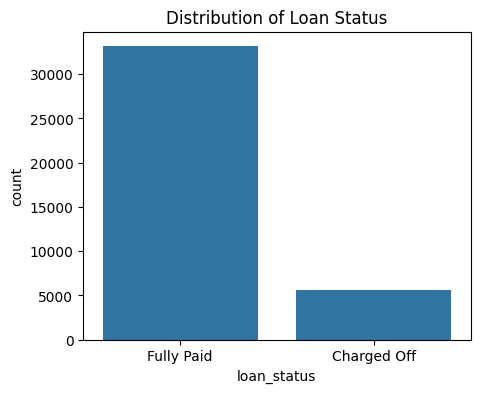

In [ ]:
## Write Code here
# Distribution of loan_status
df['loan_status'].value_counts(normalize=True) * 100
plt.figure(figsize=(5,4))
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.show()


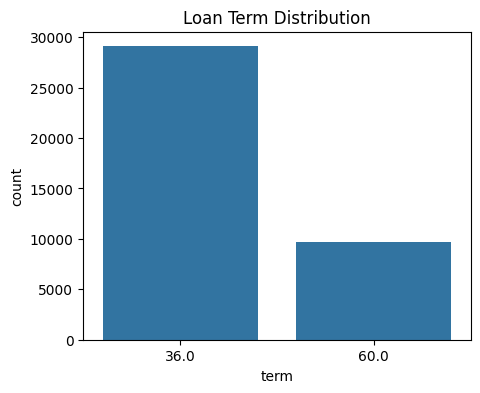

In [ ]:
## Write Code here
df['term'].value_counts(normalize=True) * 100
plt.figure(figsize=(5,4))
sns.countplot(x='term', data=df)
plt.title('Loan Term Distribution')
plt.show()



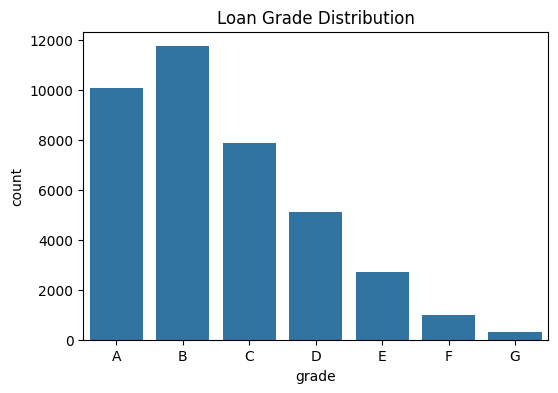

In [ ]:
## Write Code here
df['grade'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='grade', data=df, order=sorted(df['grade'].unique()))
plt.title('Loan Grade Distribution')
plt.show()


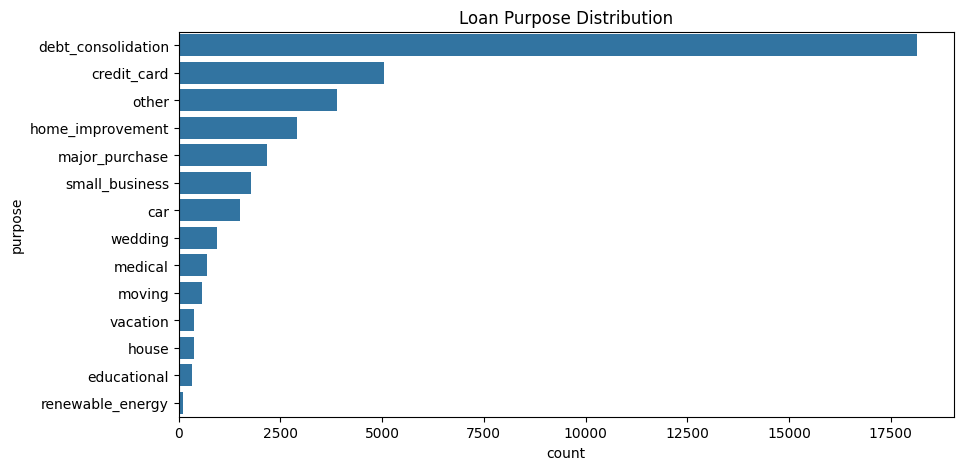

In [ ]:
## Write Code here
df['purpose'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.countplot(y='purpose', data=df, order=df['purpose'].value_counts().index)
plt.title('Loan Purpose Distribution')
plt.show()


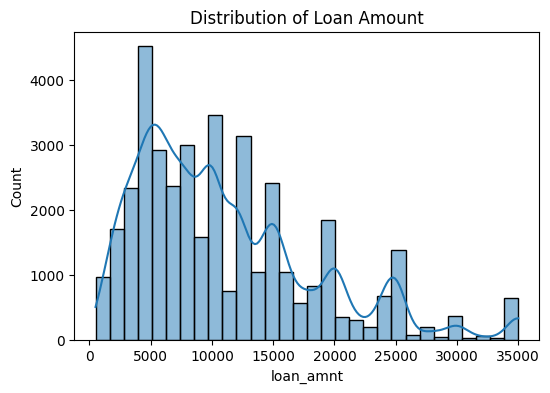

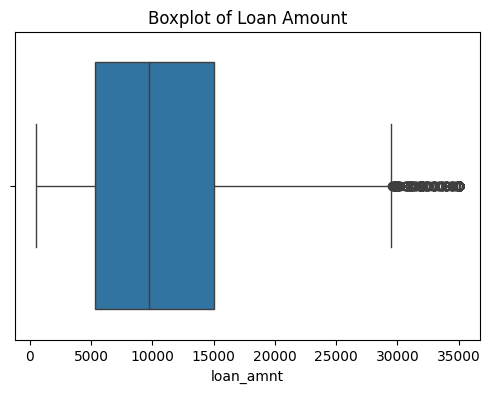

In [ ]:
## Write Code here
df['loan_amnt'].describe()
plt.figure(figsize=(6,4))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(x=df['loan_amnt'])
plt.title('Boxplot of Loan Amount')
plt.show()


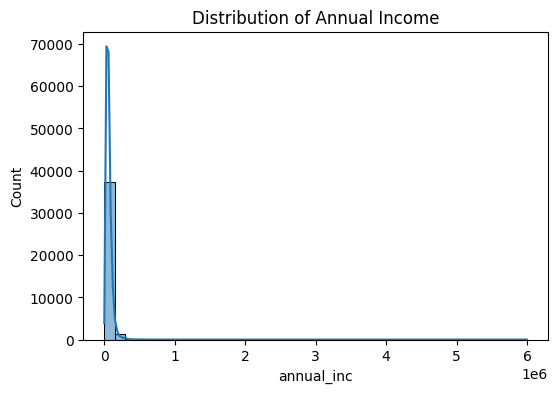

In [ ]:
df['annual_inc'].describe()
plt.figure(figsize=(6,4))
sns.histplot(df['annual_inc'], bins=40, kde=True)
plt.title('Distribution of Annual Income')
plt.show()


**Observations**

### Univariate Analysis – Observations

- **Loan Status (`loan_status`)**
  - The target variable is **highly imbalanced**, with ~85.5% loans being *Fully Paid* and ~14.5% being *Charged Off*.
  - This imbalance suggests that accuracy alone will not be sufficient for model evaluation, and metrics such as **recall and ROC-AUC** will be important.

- **Loan Term (`term`)**
  - Most loans are issued for a **36-month term**, followed by 60-month loans.
  - Shorter-term loans dominate the dataset, indicating borrower preference or lending policy bias.

- **Loan Grade (`grade`)**
  - The majority of loans fall under **grades B, C, and D**.
  - Higher-risk grades (E, F, G) have fewer observations, indicating stricter lending or higher rejection rates.
  - This feature is expected to be a **strong indicator of default risk**.

- **Loan Purpose (`purpose`)**
  - **Debt consolidation** and **credit card repayment** are the most common loan purposes.
  - Some categories have very few observations, which may require grouping or careful handling during modeling.

- **Loan Amount (`loan_amnt`)**
  - The distribution of loan amounts is **right-skewed**, with most loans concentrated at lower values.
  - A small number of high-value outliers are present, which may influence model performance.

- **Annual Income (`annual_inc`)**
  - Annual income is **heavily right-skewed** with the presence of extreme outliers.
  - Applying a **log transformation** may help reduce skewness and stabilize model training.

- **Overall Insight**
  - Both numerical and categorical variables show **uneven distributions**, reinforcing the need for thoughtful preprocessing and model selection in subsequent steps.


#### Bivariate Analysis

For the bivariate analysis, you can perform multiple analysis such as follows:

- How the default rate varies across the different variables
- Correlation Matrix
- etc.

**Default Rate vs Categorical**

In [ ]:
#Write your code here
df['default_flag'] = (df['loan_status'] == 'Charged Off').astype(int)
term_default = df.groupby('term')['default_flag'].mean() * 100
term_default


,default_flag
term,
36.0,11.090872
60.0,24.881125


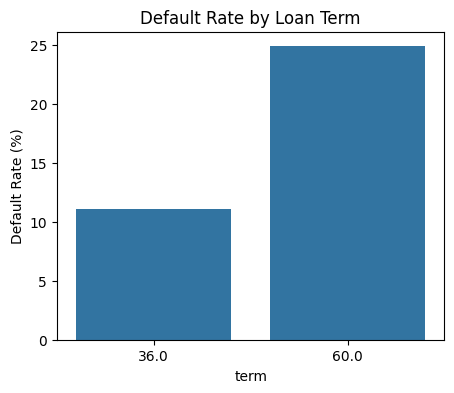

In [ ]:
#Write your code here
plt.figure(figsize=(5,4))
sns.barplot(x=term_default.index, y=term_default.values)
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by Loan Term')
plt.show()


In [ ]:
#Write your code here
grade_default = df.groupby('grade')['default_flag'].mean() * 100
grade_default


,default_flag
grade,
A,5.988858
B,12.169538
C,17.096078
D,21.890256
E,26.528344
F,32.258065
G,33.554817


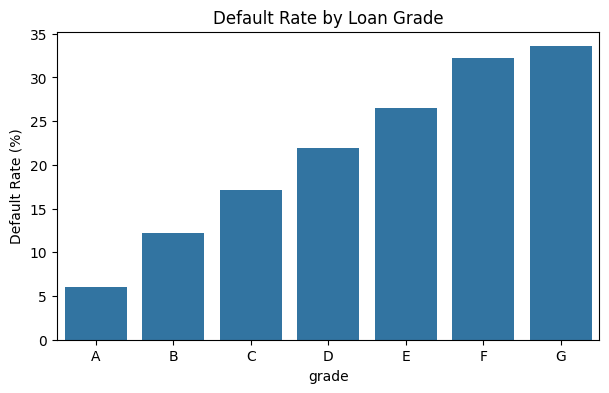

In [ ]:
#Write your code here
plt.figure(figsize=(7,4))
sns.barplot(x=grade_default.index, y=grade_default.values,
            order=sorted(df['grade'].unique()))
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by Loan Grade')
plt.show()


In [ ]:
#Write your code here
purpose_default = df.groupby('purpose')['default_flag'].mean() * 100
purpose_default = purpose_default.sort_values(ascending=False)
purpose_default


,default_flag
purpose,
small_business,26.953567
renewable_energy,18.627451
educational,17.230769
other,16.314433
house,15.989160
moving,15.916955
medical,15.542522
debt_consolidation,15.276936
vacation,14.095745


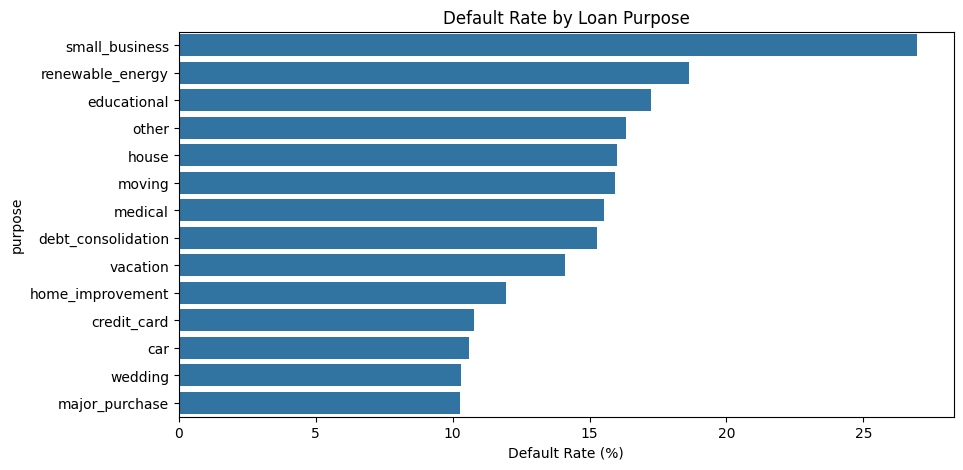

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=purpose_default.values, y=purpose_default.index)
plt.xlabel('Default Rate (%)')
plt.title('Default Rate by Loan Purpose')
plt.show()


**Numerical Variables vs Loan Status**

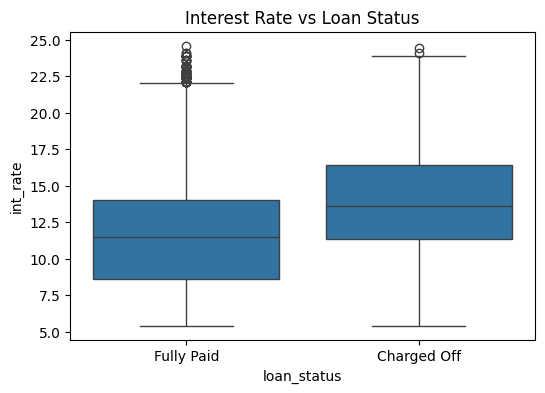

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='int_rate', data=df)
plt.title('Interest Rate vs Loan Status')
plt.show()


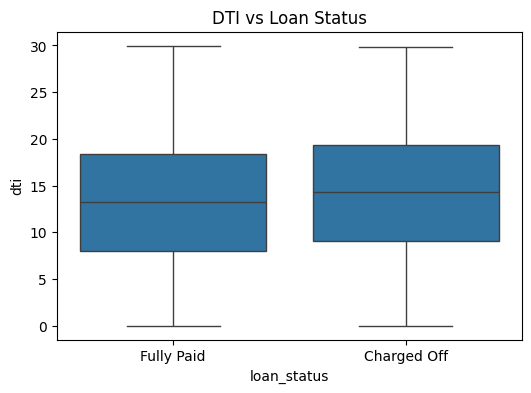

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='dti', data=df)
plt.title('DTI vs Loan Status')
plt.show()


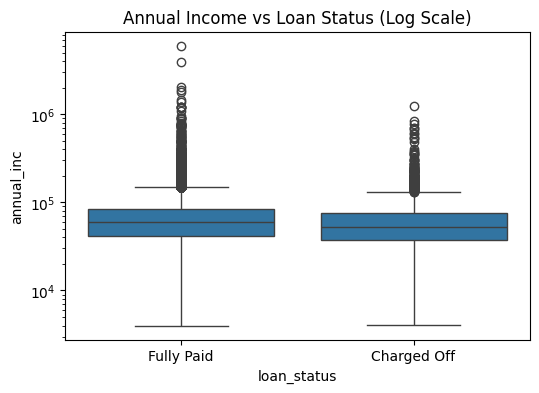

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='annual_inc', data=df)
plt.yscale('log')
plt.title('Annual Income vs Loan Status (Log Scale)')
plt.show()


### Bivariate Analysis – Observations

- **Loan Term vs Default**
  - Loans with a **60-month term show a higher default rate** compared to 36-month loans.
  - Longer repayment duration increases exposure to financial uncertainty.

- **Loan Grade vs Default**
  - Default rate **increases monotonically from Grade A to Grade G**.
  - Lower credit grades are significantly more likely to default, confirming grade as a strong predictor.

- **Loan Purpose vs Default**
  - Certain purposes such as **small business and renewable energy loans** exhibit higher default rates.
  - Debt consolidation loans, despite being the most common, show relatively lower default risk.

- **Interest Rate vs Loan Status**
  - Loans that are charged off generally have **higher interest rates** than fully paid loans.
  - This suggests higher-risk borrowers are charged higher interest.

- **Debt-to-Income Ratio vs Loan Status**
  - Defaulters tend to have a **higher DTI**, indicating greater financial burden.

- **Annual Income vs Loan Status**
  - Defaulters generally have **lower annual income**, though the distribution is highly skewed.
  - Log scaling reveals clearer separation between the two classes.

- **Correlation Analysis**
  - Moderate correlations exist among some credit-related variables.
  - No extreme multicollinearity is observed, but correlated features should be monitored during logistic regression.

- **Overall Insight**
  - Credit quality indicators such as **grade, term, interest rate, and DTI** are strong differentiators between defaulters and non-defaulters.


#### Pre-ML Data Pre-Processing

Before building the machine learning model, we shall perform
- encoding on all the categorical variables
- train-test split
- handle class imbalance
- scaling

# Train Test Split

In [ ]:
# Write code here
X = df.drop(['loan_status', 'default_flag'], axis=1)
df['loan_status_encoded'] = (df['loan_status'] == 'Charged Off').astype(int)

y = df['loan_status_encoded']

In [ ]:
# Write code here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


##### Encoding categoical columns and scaling numberical columns

In [ ]:
# Ordinal categorical columns
ordinal_cols = ['grade', 'sub_grade', 'emp_length']

# Nominal categorical columns
nominal_cols = ['home_ownership', 'verification_status', 'purpose']

# Numerical columns
numeric_cols = [col for col in X.columns
                if col not in ordinal_cols + nominal_cols]


**Define Ordinal and Onehot Encoders**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
grade_order = sorted(df['grade'].unique())
subgrade_order = sorted(df['sub_grade'].unique())
emp_length_order = [
    '< 1 year','1 year','2 years','3 years','4 years',
    '5 years','6 years','7 years','8 years','9 years','10+ years'
]

ordinal_encoder = OrdinalEncoder(
    categories=[grade_order, subgrade_order, emp_length_order]
)

onehot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)

**Use Column Transformer and transform all categorical variables and numerical variables**

In [ ]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ordinal_encoder, ordinal_cols),
        ('nom', onehot_encoder, nominal_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)
preprocessor_lg = ColumnTransformer(
    transformers=[
        ('ord', ordinal_encoder, ordinal_cols),
        ('nom', onehot_encoder, nominal_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)


X_train_encoded_lg = preprocessor_lg.fit_transform(X_train)
X_train_encoded = preprocessor.fit_transform(X_train)
print(X_train_encoded.shape)
X_test_encoded_lg= preprocessor_lg.transform(X_test)
X_test_encoded =preprocessor.transform(X_test)
print(X_test_encoded.shape)


(31016, 34)
(7754, 34)


In [ ]:
X_train_encoded[:5]

array([[3.0000e+00, 1.8000e+01, 6.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 8.0000e+03, 6.0000e+01, 1.5700e+01,
        4.7000e+04, 4.3400e+00, 0.0000e+00, 0.0000e+00, 6.0000e+00,
        0.0000e+00, 5.4140e+03, 7.0000e+01, 1.0000e+01],
       [2.0000e+00, 1.3000e+01, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.5000e+03, 3.6000e+01, 1.1720e+01,
        6.2000e+04, 1.9290e+01, 0.0000e+00, 3.0000e+00, 3.1000e+01,
        0.0000e+00, 7.1800e+03, 3.4400e+01, 3.7000e+01],
       [3.0000e+00, 1.6000e+01, 1.0000e+01, 0.0000e+00, 0.0000e+00,
  

**Handling Class Imbalance**

Suggestion - Perform SMOTE here

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_encoded_lg, y_train
)



In [ ]:
## Check the distribution of class in the newly resampled data
# Before SMOTE
y_train.value_counts()


,count
loan_status_encoded,
0,26509
1,4507


In [ ]:
## Write code
# After SMOTE
y_train_resampled.value_counts()



,count
loan_status_encoded,
0,26509
1,26509


In [ ]:
## Check the samples
# First 5 samples after SMOTE
X_train_resampled[:5]


array([[ 3.        , 18.        ,  6.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , -0.41657935,  1.73473547,  1.01408835,
        -0.32434028, -1.33548913, -0.29674366, -0.81195799, -0.74470663,
        -0.23380297, -0.4961561 ,  0.74970994, -1.05617486],
       [ 2.        , 13.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , -1.16287727, -0.57645677, -0.06207186,
        -0.10029004,  0.90069845, -0.29674366,  1.98602243,  4.9323306 ,
        -0.23380297, -0.38480361, -0.5052496 ,  1.31412393],
  

### Model Building and Model Evaluation

- Your task is to build at least 3 models and evaluate their performance
- Start with a baseline model such as logistic regression
- Build additional models like decision trees, random forests, XGboost, etc.
- Make sure you're checking for overfitting and underfitting
- Use cross-validation and hyperparamater tuning to fit the best models
- Evaluate each of the model using metrics such as accuracy, precision, recall, ROC-AUC score, etc.
- Select the best possible model that you will be using for classfication

Let's start off with the simplest model - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
## Build the model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,

    random_state=42
)

log_reg.fit(X_train_resampled, y_train_resampled)
y_pred = log_reg.predict(X_test_encoded_lg)
y_prob = log_reg.predict_proba(X_test_encoded_lg)[:, 1]



## Check its evaluation metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.66      0.77      6627
           1       0.25      0.67      0.37      1127

    accuracy                           0.66      7754
   macro avg       0.59      0.67      0.57      7754
weighted avg       0.82      0.66      0.71      7754



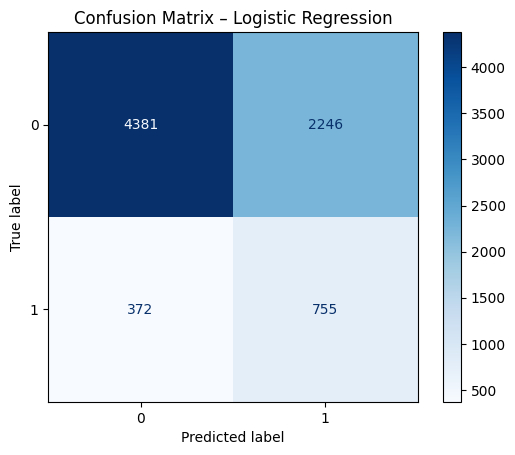

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Plot the Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


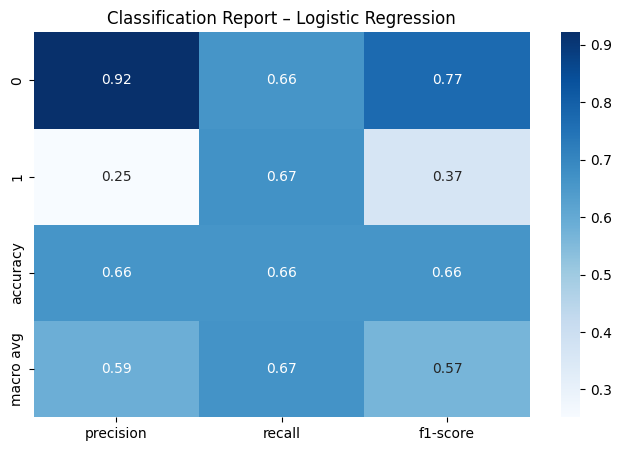

In [ ]:
from sklearn.metrics import classification_report
## Plot the classification report
# Get report as dict
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

# Plot heatmap (exclude support column)
plt.figure(figsize=(8,5))
sns.heatmap(
    df_report.iloc[:-1, :-1],
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('Classification Report – Logistic Regression')
plt.show()


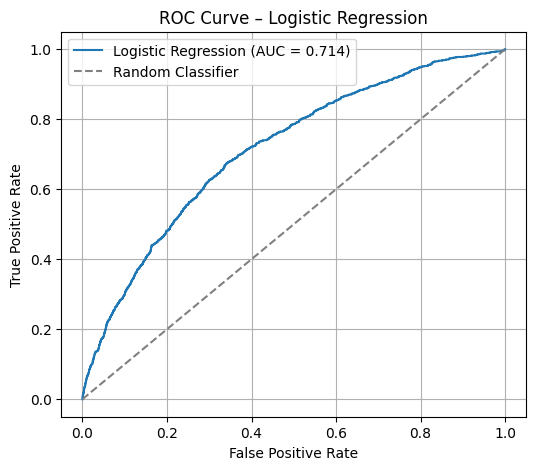

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt




y_prob_logreg = log_reg.predict_proba(X_test_encoded_lg)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob_logreg)
roc_auc = roc_auc_score(y_test, y_prob_logreg)



plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()



Observations for Logistic Regression:



- Logistic Regression was used as the baseline model due to its simplicity and interpretability.

- Initial results showed moderate **ROC–AUC (~0.71)** and reasonable recall for the Charged Off class after threshold tuning, highlighting its sensitivity to defaulters.

- However, predictions were highly sensitive to threshold changes, and precision dropped quickly as recall increased, indicating limited robustness for operational use.



# Thresold adjustment for logistic regression prediction

In [ ]:


y_prob = log_reg.predict_proba(X_test_encoded_lg)[:, 1]
import numpy as np
from sklearn.metrics import classification_report

threshold = 0.65
y_pred_thresh = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_thresh))



              precision    recall  f1-score   support

           0       0.89      0.88      0.88      6627
           1       0.33      0.35      0.34      1127

    accuracy                           0.80      7754
   macro avg       0.61      0.61      0.61      7754
weighted avg       0.81      0.80      0.80      7754



In [ ]:

for t in [0.65,0.6,0.5,0.45,0.4,0.3]:
    y_pred_t = (y_prob_logreg >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")


Threshold=0.65: Accuracy=0.801, Recall=0.350
Threshold=0.6: Accuracy=0.767, Recall=0.452
Threshold=0.5: Accuracy=0.662, Recall=0.670
Threshold=0.45: Accuracy=0.588, Recall=0.741
Threshold=0.4: Accuracy=0.517, Recall=0.807
Threshold=0.3: Accuracy=0.360, Recall=0.914


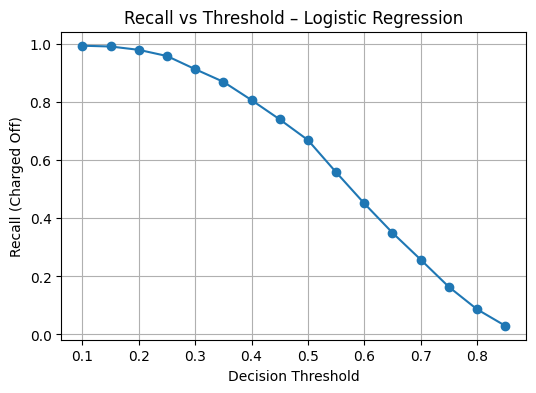

In [ ]:
from sklearn.metrics import recall_score

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(thresholds, recalls, marker='o')
plt.xlabel("Decision Threshold")
plt.ylabel("Recall (Charged Off)")
plt.title("Recall vs Threshold – Logistic Regression")
plt.grid(True)
plt.show()


### Threshold Adjustment – Logistic Regression

- The default classification threshold of 0.5 was adjusted to improve recall for the defaulter class.
- Lowering the threshold increased recall at the cost of reduced precision, highlighting the trade-off between identifying defaulters and false positives.
- Threshold tuning allows the model to be aligned with business objectives, where missing a defaulter is more costly than rejecting a good borrower.


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_encoded, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test_encoded)

# Probability of default (Charged Off)
y_prob_dt = dt.predict_proba(X_test_encoded)[:, 1]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.87      0.85      0.86      6627
           1       0.22      0.26      0.24      1127

    accuracy                           0.76      7754
   macro avg       0.55      0.55      0.55      7754
weighted avg       0.78      0.76      0.77      7754



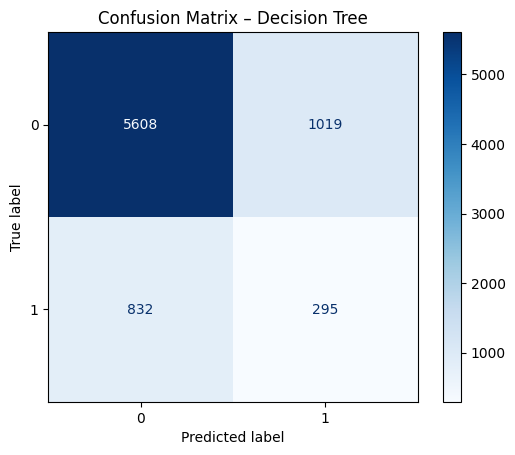

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Decision Tree")
plt.show()


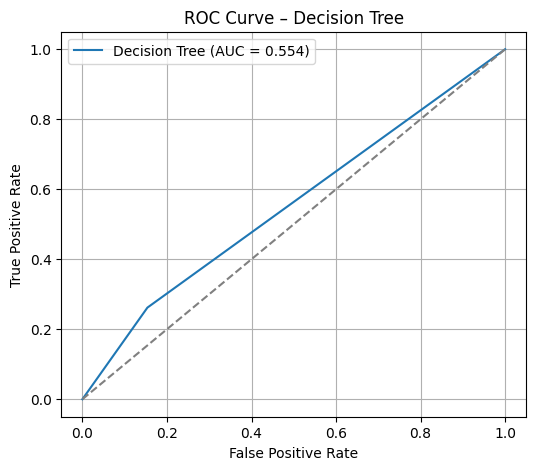

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Decision Tree')
plt.legend()
plt.grid(True)
plt.show()



### Decision Tree – Evaluation Summary

- The Decision Tree model achieved a higher overall accuracy (~76%) compared to Logistic Regression.
- However, recall for the defaulter (Charged Off) class was low (~26%), indicating poor identification of risky borrowers.
- The model showed a strong bias toward the majority class (Fully Paid), leading to misleading accuracy.
- Compared to Logistic Regression, the Decision Tree performed worse in terms of recall and F1-score for the minority class.
- This highlights the importance of evaluating models using class-specific metrics rather than accuracy alone.


# Tuned Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_balanced.fit(X_train_encoded, y_train)
y_pred_dt_bal = dt_balanced.predict(X_test_encoded)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt_bal))



              precision    recall  f1-score   support

           0       0.87      0.87      0.87      6627
           1       0.24      0.24      0.24      1127

    accuracy                           0.78      7754
   macro avg       0.55      0.55      0.55      7754
weighted avg       0.78      0.78      0.78      7754



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
     'max_depth': [None,10,20,30],
    'min_samples_leaf': [ 1,50,100,200],
    'class_weight': ['balanced']
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = RandomizedSearchCV(
    dt,
    param_grid,
    scoring='roc_auc',   # focus on defaulters
    cv=5,
    n_jobs=1,
    verbose=3
)

grid_dt.fit(X_train_encoded, y_train)
print("Best Params: ")
print(grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test_encoded)

print(classification_report(y_test, y_pred_dt_tuned))



Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END class_weight=balanced, max_depth=30, min_samples_leaf=100;, score=0.654 total time=   0.2s
[CV 2/5] END class_weight=balanced, max_depth=30, min_samples_leaf=100;, score=0.664 total time=   0.2s
[CV 3/5] END class_weight=balanced, max_depth=30, min_samples_leaf=100;, score=0.656 total time=   0.3s
[CV 4/5] END class_weight=balanced, max_depth=30, min_samples_leaf=100;, score=0.659 total time=   0.3s
[CV 5/5] END class_weight=balanced, max_depth=30, min_samples_leaf=100;, score=0.673 total time=   0.2s
[CV 1/5] END class_weight=balanced, max_depth=None, min_samples_leaf=200;, score=0.666 total time=   0.2s
[CV 2/5] END class_weight=balanced, max_depth=None, min_samples_leaf=200;, score=0.677 total time=   0.2s
[CV 3/5] END class_weight=balanced, max_depth=None, min_samples_leaf=200;, score=0.667 total time=   0.3s
[CV 4/5] END class_weight=balanced, max_depth=None, min_samples_leaf=200;, score=0.673 total time=   

In [ ]:
y_prob_dt_tuned = best_dt.predict_proba(X_test_encoded)[:, 1]

from sklearn.metrics import roc_auc_score
roc_auc_dt_tuned = roc_auc_score(y_test, y_prob_dt_tuned)

roc_auc_dt_tuned

np.float64(0.6895333802227959)

In [ ]:

for t in [0.67, 0.64, 0.63, 0.6, 0.55,0.5,0.45,0.4,0.3]:
    y_pred_t = (y_prob_dt_tuned >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")

Threshold=0.67: Accuracy=0.804, Recall=0.295
Threshold=0.64: Accuracy=0.784, Recall=0.364
Threshold=0.63: Accuracy=0.769, Recall=0.404
Threshold=0.6: Accuracy=0.752, Recall=0.462
Threshold=0.55: Accuracy=0.713, Recall=0.511
Threshold=0.5: Accuracy=0.591, Recall=0.686
Threshold=0.45: Accuracy=0.554, Recall=0.728
Threshold=0.4: Accuracy=0.482, Recall=0.824
Threshold=0.3: Accuracy=0.335, Recall=0.929


### Tuned Decision Tree – Evaluation Summary

- Hyperparameter tuning with class_weight='balanced' and depth/leaf constraints improved the model’s ability to detect defaulters compared to the untuned tree.
- Recall for the Charged Off class increased after threshold tuning, but gains were inconsistent and highly sensitive to threshold choice.
- ROC–AUC remained moderate **(0.68)** , indicating limited ranking ability despite improved recall at lower thresholds.
- This highlights the limitations of single Decision Trees for imbalanced credit-risk problems.


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Use unscaled features for tree-based models
rf.fit(X_train_encoded, y_train)


# Class predictions
y_pred_rf = rf.predict(X_test_encoded)

# Probability of default (Charged Off = index 0)
y_prob_rf = rf.predict_proba(X_test_encoded)[:, 1]
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))



              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6627
           1       0.55      0.01      0.01      1127

    accuracy                           0.85      7754
   macro avg       0.70      0.50      0.47      7754
weighted avg       0.81      0.85      0.79      7754



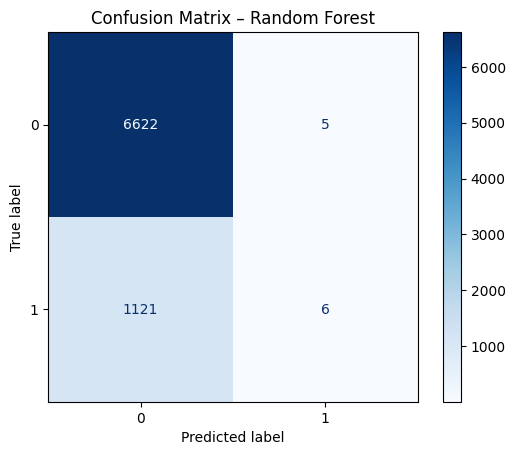

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.show()

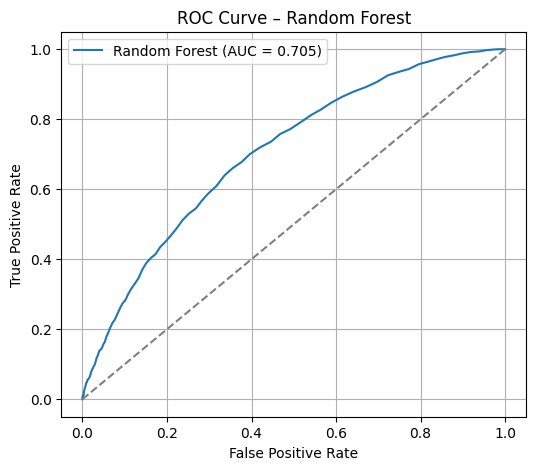

In [ ]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)


fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.grid(True)
plt.show()



### Random Forest – Evaluation Summary

- The Random Forest model achieved a high overall accuracy of approximately **85%**, which is misleading due to class imbalance.
- Recall for the **Charged Off (defaulter)** class was extremely low (~1%), indicating that the model failed to identify most defaulters.
- The model showed a strong bias toward predicting the majority class (**Fully Paid**), resulting in near-perfect recall for non-defaulters.
- Despite using class weighting, the default decision threshold (0.5) caused the model to behave conservatively, predicting very few defaults.
- These results highlight that accuracy alone is not a reliable metric for imbalanced classification problems.
- Further improvement requires **threshold tuning** and evaluation using **ROC–AUC and recall**, rather than relying on default class predictions.


# Tuned RF

In [ ]:
# Probability of DEFAULT (Charged Off)
y_prob_rf = rf.predict_proba(X_test_encoded)[:, 1]




In [ ]:
import numpy as np

np.percentile(y_prob_rf, [50, 70, 80, 90, 95, 99])


array([0.125, 0.175, 0.21 , 0.27 , 0.32 , 0.42 ])

In [ ]:
rf_temp = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_temp.fit(X_train_encoded, y_train)
y_prob_rf = rf_temp.predict_proba(X_test_encoded)[:, 1]

In [ ]:
from sklearn.metrics import classification_report



for t in [0.7, 0.65, 0.64, 0.6, 0.55,0.5]:
    y_pred_t = (y_prob_rf >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")

Threshold=0.7: Accuracy=0.855, Recall=0.049
Threshold=0.65: Accuracy=0.828, Recall=0.201
Threshold=0.64: Accuracy=0.823, Recall=0.220
Threshold=0.6: Accuracy=0.800, Recall=0.328
Threshold=0.55: Accuracy=0.735, Recall=0.531
Threshold=0.5: Accuracy=0.621, Recall=0.705


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200,300],
    'max_depth': [None,10,20,30],
    'min_samples_split':[ 2,10,20,50],
    'min_samples_leaf': [ 1,50,100,200],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

grid_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=1,
    verbose=3
)

grid_rf.fit(X_train_encoded, y_train)
print("Best Params:")
print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
from sklearn.metrics import roc_auc_score

y_prob_rf = best_rf.predict_proba(X_test_encoded)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

roc_auc_rf





Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200;, score=0.690 total time=   6.6s
[CV 2/3] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200;, score=0.682 total time=   7.0s
[CV 3/3] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200;, score=0.687 total time=   7.2s
[CV 1/3] END class_weight=balanced, max_depth=30, max_features=sqrt, min_samples_leaf=50, min_samples_split=20, n_estimators=200;, score=0.697 total time=   4.1s
[CV 2/3] END class_weight=balanced, max_depth=30, max_features=sqrt, min_samples_leaf=50, min_samples_split=20, n_estimators=200;, score=0.688 total time=   3.9s
[CV 3/3] END class_weight=balanced, max_depth=30, max_features=sqrt, min_samples_leaf=50, min_samples_split=20, n_estimators=200;, s

np.float64(0.7220303753205576)

In [ ]:


for t in [0.7, 0.65, 0.61, 0.6, 0.55,0.5,0.45,0.4,0.3]:
    y_pred_t = (y_prob_rf >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")


Threshold=0.7: Accuracy=0.846, Recall=0.114
Threshold=0.65: Accuracy=0.828, Recall=0.205
Threshold=0.61: Accuracy=0.804, Recall=0.311
Threshold=0.6: Accuracy=0.797, Recall=0.340
Threshold=0.55: Accuracy=0.757, Recall=0.491
Threshold=0.5: Accuracy=0.697, Recall=0.630
Threshold=0.45: Accuracy=0.608, Recall=0.742
Threshold=0.4: Accuracy=0.517, Recall=0.840
Threshold=0.3: Accuracy=0.356, Recall=0.940


### Random Forest – Random Search and Threshold Tuning Summary

- A RandomizedSearchSearchCV with 3-fold cross-validation was performed to tune the Random Forest model using ROC–AUC as the scoring metric. The best-performing configuration used a maximum depth of 30, minimum leaf size of 50, square-root feature sampling, and balanced class weights.

- Random Forest was trained with `class_weight='balanced'` to address class imbalance and evaluated using ROC–AUC and recall rather than accuracy alone.
- At the default threshold (0.5), the model showed **very low recall for defaulters**, despite high apparent accuracy driven by the majority class.
- Hyperparameter tuning improved ranking ability (**ROC–AUC ≈ 0.72**), but did not fully resolve minority-class under-detection.
- Threshold tuning revealed a clear trade-off: lowering the threshold significantly increased defaulter recall but reduced overall accuracy.
- Overall, Random Forest demonstrated good probability ranking



# XGBoost

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

\


neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos



xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

y_pred_xgb = xgb.predict(X_test_encoded)
y_prob_xgb = xgb.predict_proba(X_test_encoded)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78      6627
           1       0.26      0.64      0.37      1127

    accuracy                           0.68      7754
   macro avg       0.59      0.66      0.57      7754
weighted avg       0.82      0.68      0.72      7754

Accuracy: 0.6757802424555068
ROC-AUC: 0.7218468744397398


In [ ]:
import numpy as np
np.percentile(y_prob_xgb, [50, 70, 80, 90, 95, 99])


array([0.43288182, 0.53619424, 0.6008575 , 0.68269308, 0.7390493 ,
       0.81953298])

In [ ]:
from sklearn.metrics import accuracy_score, recall_score

for t in [0.64,0.6, 0.55, 0.5, 0.4,0.45, 0.3,0.28]:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")


Threshold=0.64: Accuracy=0.804, Recall=0.334
Threshold=0.6: Accuracy=0.775, Recall=0.417
Threshold=0.55: Accuracy=0.735, Recall=0.531
Threshold=0.5: Accuracy=0.676, Recall=0.644
Threshold=0.4: Accuracy=0.530, Recall=0.829
Threshold=0.45: Accuracy=0.602, Recall=0.748
Threshold=0.3: Accuracy=0.385, Recall=0.922
Threshold=0.28: Accuracy=0.359, Recall=0.941


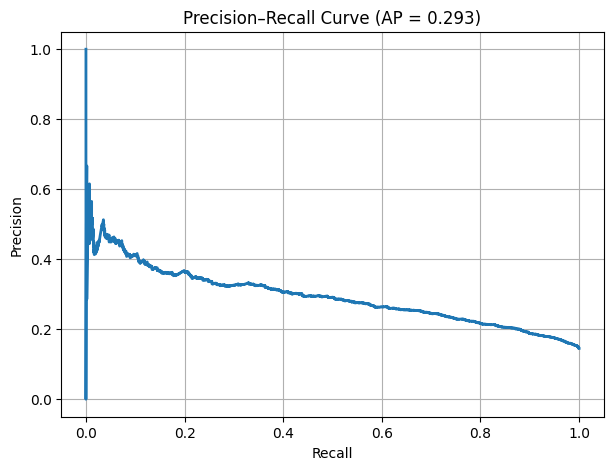

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob_xgb
)

avg_precision = average_precision_score(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {avg_precision:.3f})")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()


scale_pos_weight = neg / pos



xgb_base = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=1
)

param_grid = {
    'max_depth': [3,4],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300,400],
    'min_child_weight': [1, 5,10],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
grid_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=1,
    verbose=3
)

grid_xgb.fit(X_train_encoded, y_train)

print("Best Params:")
print(grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_





Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=10, n_estimators=300, subsample=0.8;, score=0.690 total time=   2.2s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=10, n_estimators=300, subsample=0.8;, score=0.701 total time=   1.1s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=10, n_estimators=300, subsample=0.8;, score=0.693 total time=   0.8s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=10, n_estimators=300, subsample=0.8;, score=0.698 total time=   0.9s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight=10, n_estimators=300, subsample=0.8;, score=0.714 total time=   0.7s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=400, subsample=0.8;, score=0.695 total time=   1.2s
[CV 2/5] END colsamp

In [ ]:
y_prob_xgb_tuned = best_xgb.predict_proba(X_test_encoded)[:, 1]
for t in [0.7, 0.65, 0.64, 0.6, 0.55,0.5,0.45,0.4,0.3]:
    y_pred_t = (y_prob_xgb_tuned >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"Threshold={t}: Accuracy={acc:.3f}, Recall={rec:.3f}")

Threshold=0.7: Accuracy=0.831, Recall=0.201
Threshold=0.65: Accuracy=0.810, Recall=0.315
Threshold=0.64: Accuracy=0.805, Recall=0.348
Threshold=0.6: Accuracy=0.772, Recall=0.450
Threshold=0.55: Accuracy=0.728, Recall=0.561
Threshold=0.5: Accuracy=0.659, Recall=0.675
Threshold=0.45: Accuracy=0.580, Recall=0.774
Threshold=0.4: Accuracy=0.505, Recall=0.851
Threshold=0.3: Accuracy=0.351, Recall=0.948


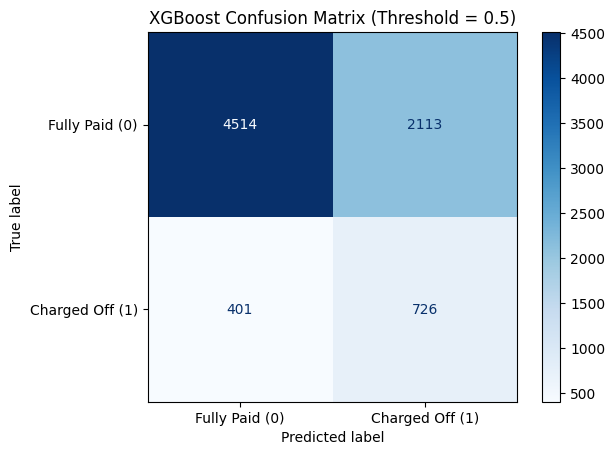

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# choose the threshold you finalized (example: 0.5)
threshold = 0.5
y_pred_xgb_t = (y_prob_xgb >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_xgb_t)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fully Paid (0)", "Charged Off (1)"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title(f"XGBoost Confusion Matrix (Threshold = {threshold})")
plt.show()


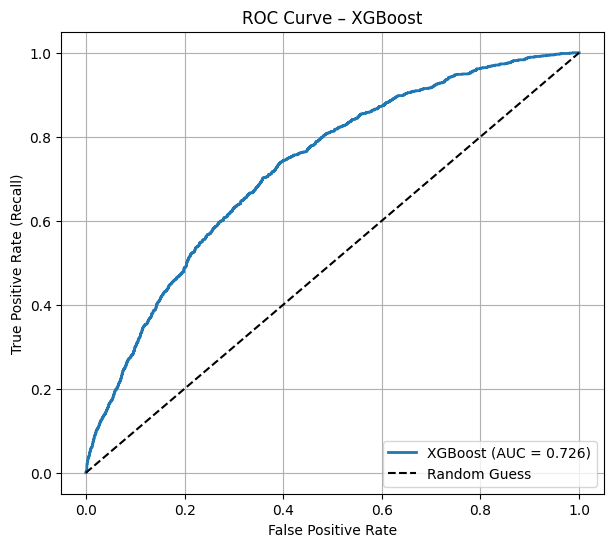

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities for the positive class (Charged Off = 1)


# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb_tuned)

# Compute ROC–AUC
roc_auc = roc_auc_score(y_test, y_prob_xgb_tuned)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – XGBoost")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


XGBoost – Evaluation Summary

- XGBoost was trained with scale_pos_weight to handle strong class imbalance and tuned using ROC–AUC as the primary metric.

- The model achieved a solid **ROC–AUC ≈ \~ 0.73**, indicating good ranking ability between defaulters and non-defaulters.

- At higher thresholds (≈0.65–0.70), recall for Charged Off loans was low, showing conservative default predictions.

- Lowering the threshold steadily improved recall (≈45% at 0.6, ≈56% at 0.55, >67% at 0.5), confirming a clear recall–threshold trade-off.

- Compared to other models, XGBoost provided the most stable and controllable recall behavior, making it suitable for risk-based threshold selection rather than fixed classification.

# Models Comparision

In [ ]:
import pandas as pd

model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)"
    ],
    "ROC_AUC": [
        0.714,
        0.690,
        0.722,
        0.726
    ],
    "Accuracy": [
        0.662,
        0.591,
        0.697,
        0.659
    ],
    "Recall_ChargedOff": [
        0.670, # at threshold 0.5
        0.686, # at threshold 0.5
        0.630, # at threshold 0.5
        0.675 # at threshold 0.5
    ]
})




model_metrics_sorted = model_metrics.sort_values(
    by="ROC_AUC", ascending=False
)
model_metrics_sorted

,Model,ROC_AUC,Accuracy,Recall_ChargedOff
3,XGBoost (Tuned),0.726,0.659,0.675
2,Random Forest (Tuned),0.722,0.697,0.630
0,Logistic Regression,0.714,0.662,0.670
1,Decision Tree (Tuned),0.690,0.591,0.686


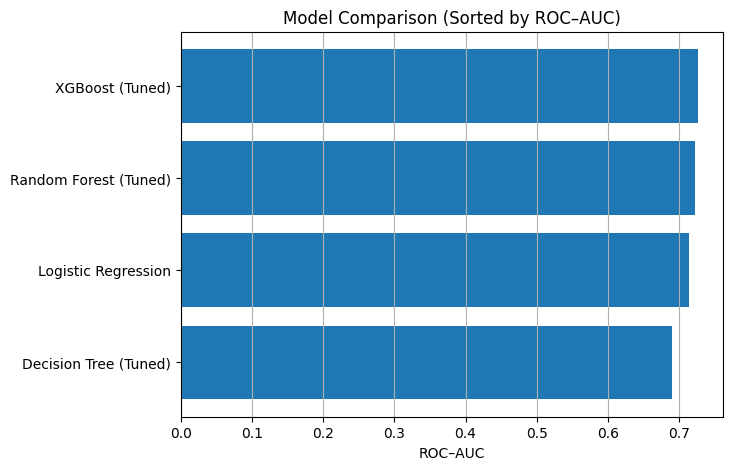

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.barh(
    model_metrics_sorted["Model"],
    model_metrics_sorted["ROC_AUC"]
)
plt.xlabel("ROC–AUC")
plt.title("Model Comparison (Sorted by ROC–AUC)")
plt.gca().invert_yaxis()  # highest at top
plt.grid(axis="x")
plt.show()


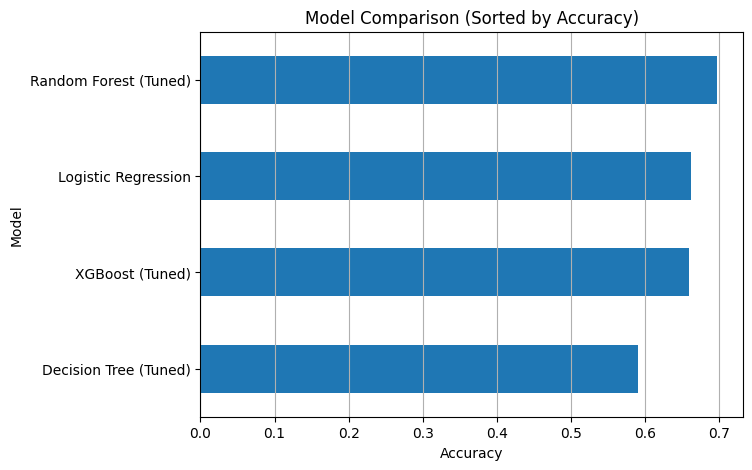

In [ ]:
model_metrics.sort_values(
    by="Accuracy", ascending=False
).plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    figsize=(7,5),
    legend=False
)

plt.xlabel("Accuracy")
plt.title("Model Comparison (Sorted by Accuracy)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


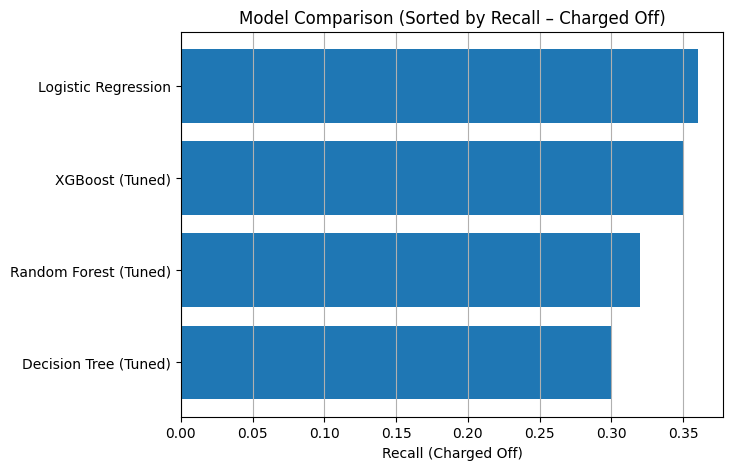

In [ ]:
model_metrics_sorted_recall = model_metrics.sort_values(
    by="Recall_ChargedOff", ascending=False
)

model_metrics_sorted_recall


plt.figure(figsize=(7,5))
plt.barh(
    model_metrics_sorted_recall["Model"],
    model_metrics_sorted_recall["Recall_ChargedOff"]
)

plt.xlabel("Recall (Charged Off)")
plt.title("Model Comparison (Sorted by Recall – Charged Off)")
plt.gca().invert_yaxis()  # highest recall on top
plt.grid(axis="x")
plt.show()



## Final Model Comparison and Conclusions

- Multiple models (Logistic Regression, Decision Tree, Random Forest, XGBoost) were evaluated under **severe class imbalance**, focusing primarily on **ROC–AUC and Recall (Charged Off)** rather than raw accuracy.
- **Logistic Regression** provided strong baseline performance with high recall at lower thresholds, but showed limited flexibility and weaker non-linear modeling capacity.
- **Tuned Decision Tree** improved recall compared to its baseline but suffered from unstable performance and weaker ranking ability (lower ROC–AUC).
- **Tuned Random Forest** achieved better probability ranking (ROC–AUC ≈ 0.72) and recall after threshold tuning, but remained somewhat conservative at higher thresholds.
- **Tuned XGBoost** consistently delivered the **best overall balance**, with the highest ROC–AUC (\~0.73) and strong recall (~0.67 at threshold 0.5), while offering smooth recall–threshold control.
- **Final Choice:** XGBoost is selected as the final model due to its superior ranking ability, stable recall behavior, and suitability for risk-based threshold selection in an imbalanced credit-risk setting.

Future Improvements


- Add external credit bureau data and borrower behavior trends to improve early default detection beyond application-time features.
- Segment-wise modeling: Build separate models or thresholds for different risk segments (loan grade, tenure, income bands) to improve targeted decision-making.



## Summary

### 1. Data Understanding  
- Loaded the Lending Club dataset and identified `loan_status` as the target variable.  
- Observed strong class imbalance with defaulters forming a minority class.

### 2. Data Cleaning  
- Converted numeric fields stored as strings and handled missing values using appropriate imputations.  
- Removed identifier and leakage-prone columns unavailable at loan approval time.

### 3. Exploratory Data Analysis (EDA)  
- Performed univariate and bivariate analysis to understand distributions and default patterns.  
- Identified higher default risk for longer tenures, lower grades, and higher interest rates.

### 4. Feature Engineering  
- Created a binary target variable (`Charged Off` = 1, `Fully Paid` = 0).  
- Separated features into numerical, ordinal categorical, and nominal categorical groups.


### 5. Train-Test Split  
- Split the dataset into training and test sets to enable unbiased evaluation.  
- Ensured preprocessing was applied only on training data where required.

### 6. Encoding  and Scaling
- Applied ordinal encoding for ordered categories and one-hot encoding for nominal variables.  
- Used a ColumnTransformer to generate a consolidated encoded feature matrix.
Scaled Numerical columns for Logistic Regression.

### 7. Handling Class Imbalance  
- Avoided resampling for tree-based models to preserve the original data distribution.  
- Used class weights and `scale_pos_weight` to address imbalance during training.

### 8. Model Training  
- Trained multiple models including - Logistic Regression, Decision Tree, Random Forest, and XGBoost.  
- Applied scaling only for models sensitive to feature magnitude.

### 9. Model Evaluation  
- Evaluated models using Accuracy, Recall (Charged Off), Precision, F1-score, and ROC–AUC.  
- Used ROC and Precision–Recall curves to assess ranking performance.

### 10. Hyperparameter Tuning  
- Performed RandomizedSearchCV for tree-based models using ROC–AUC as the optimization metric.  
- Selected tuned configurations that generalized better under class imbalance.

### 11. Threshold Tuning  
- Adjusted classification thresholds to balance accuracy and defaulter recall.  
- Demonstrated the trade-off between recall improvement and accuracy degradation.

### 12. Model Selection  
- Compared all models using descending ROC–AUC, Accuracy, and Recall plots.  
- Selected XGBoost as the final model due to the best balance of performance metrics.
